In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("data/stud.csv")

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df[df.duplicated()]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


In [9]:
df["gender"].unique()

array(['female', 'male'], dtype=object)

In [10]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [11]:
df["parental_level_of_education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [12]:
df["race_ethnicity"].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [13]:
df["test_preparation_course"].unique()

array(['none', 'completed'], dtype=object)

In [14]:
Numerical_columns=[ feature for feature in df.columns if df[feature].dtype!="object"]
Categorical_columns=[ feature for feature in df.columns if df[feature].dtype=="object"]

In [15]:
print (f"total numerical  features={len(Numerical_columns)}")
print (f"total categorical features={len(Categorical_columns)}")

total numerical  features=3
total categorical features=5


In [16]:
df["total_score"]=df["reading_score"]+df["math_score"]+df["writing_score"]
df["Average_score"]=df["total_score"]/3

In [17]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [18]:
math_full=df[df["math_score"]==100]["Average_score"].count()
print(f"Number of students who got full marks in math={math_full}")
writing_full=df[df["writing_score"]==100]["Average_score"].count()
print(f"Number of students who got full marks in writing={writing_full}")
reading_full=df[df["reading_score"]==100]["Average_score"].count()
print(f"Number of students who got full marks in reading={reading_full}")


Number of students who got full marks in math=7
Number of students who got full marks in writing=14
Number of students who got full marks in reading=17


## Data analysis  

In [19]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Text(0.5, 1.0, 'marks distribution against gender')

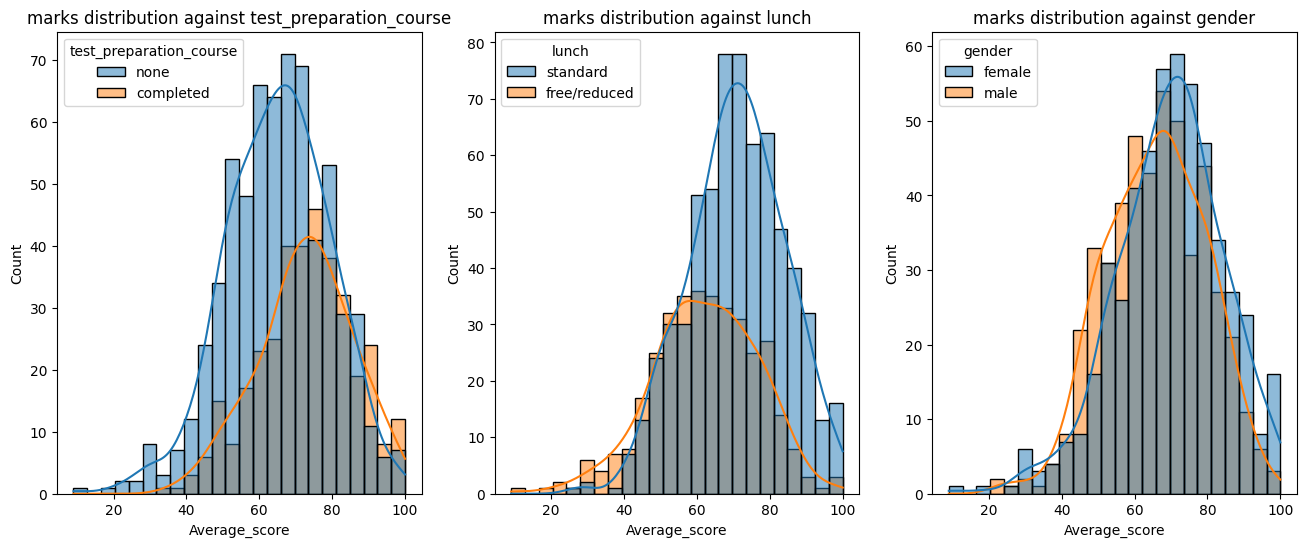

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.histplot(
    data=df,
    x="Average_score",
    kde=True,
    hue="test_preparation_course",
    ax=axes[0]
)

axes[0].set_title("marks distribution against test_preparation_course")
sns.histplot(
    data=df,
    x="Average_score",
    kde=True,
    hue="lunch",
    ax=axes[1]
)

axes[1].set_title("marks distribution against lunch")
sns.histplot(
    data=df,
    x="Average_score",
    kde=True,
    hue="gender",
    ax=axes[2]
)

axes[2].set_title("marks distribution against ")


#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

#####  Insights
- Female students tend to perform well then male students.

#### Insights with rsepect to preparation course
- Students whose avg_marks is above 90 ,have completed the course
- All students having the perfect avg_marks  have completed the course

Text(0.5, 1.0, 'number distribution against test_preparation_course and gender together')

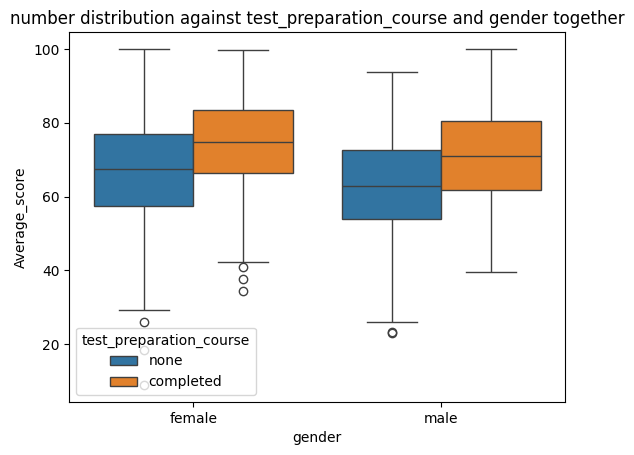

In [21]:
sns.boxplot(data=df,x="gender",y="Average_score",hue="test_preparation_course")
plt.title("number distribution against test_preparation_course and gender together")

Text(0.5, 1.0, 'marks distribution against parental_level_of_education')

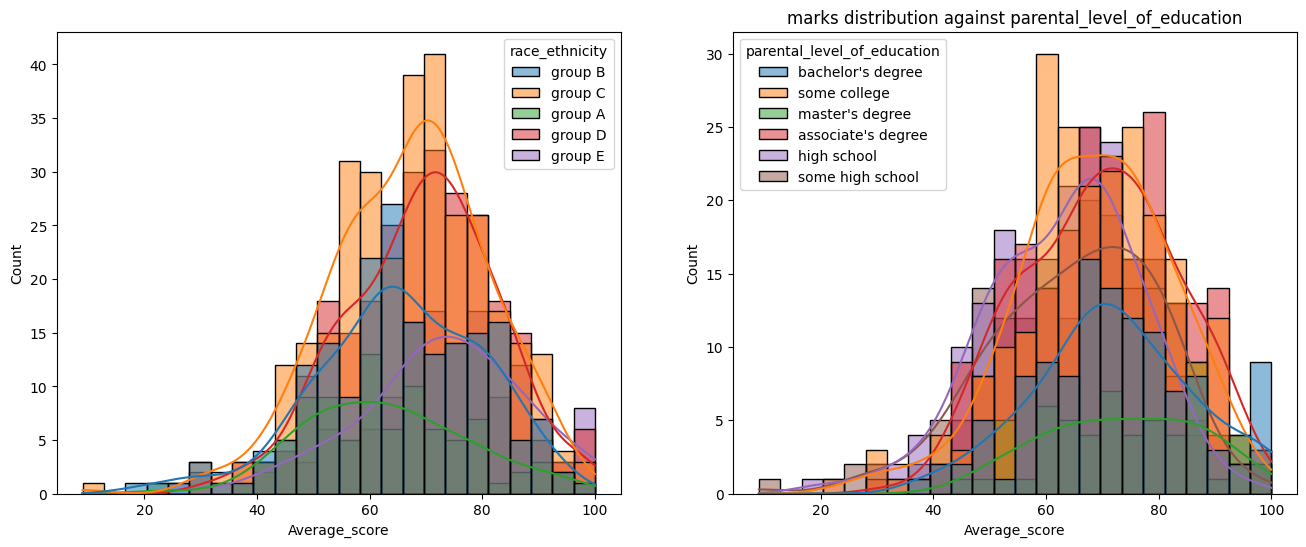

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x="Average_score",
    kde=True,
    hue="race_ethnicity",
    ax=axes[0]
)
axes[1].set_title("marks distribution against race_ethnicity")

sns.histplot(
    data=df,
    x="Average_score",
    kde=True,
    hue="parental_level_of_education",
    ax=axes[1]
)

axes[1].set_title("marks distribution against parental_level_of_education")

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

### 5. Conclusions
- Student's Performance is related with lunch, race
- Females lead in pass percentage and also are top-scorers
- Finishing preparation course is benefitial.